<a href="https://colab.research.google.com/github/Keshav-Agrawal654/Keshav_23FE10CSE00810_MLlab_project/blob/main/Test1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape : (569, 30)
Classes       : ['malignant' 'benign']
Class counts  :
 target
benign       357
malignant    212
Name: count, dtype: int64

First 5 rows:
    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4  

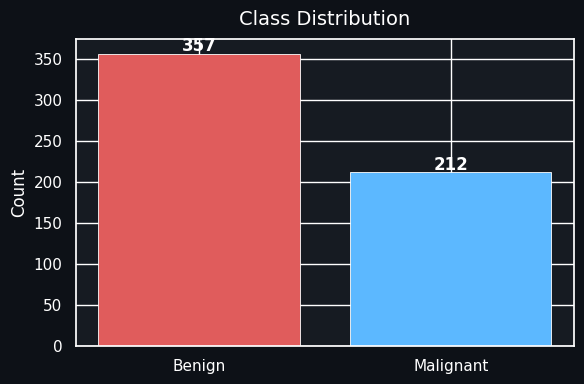

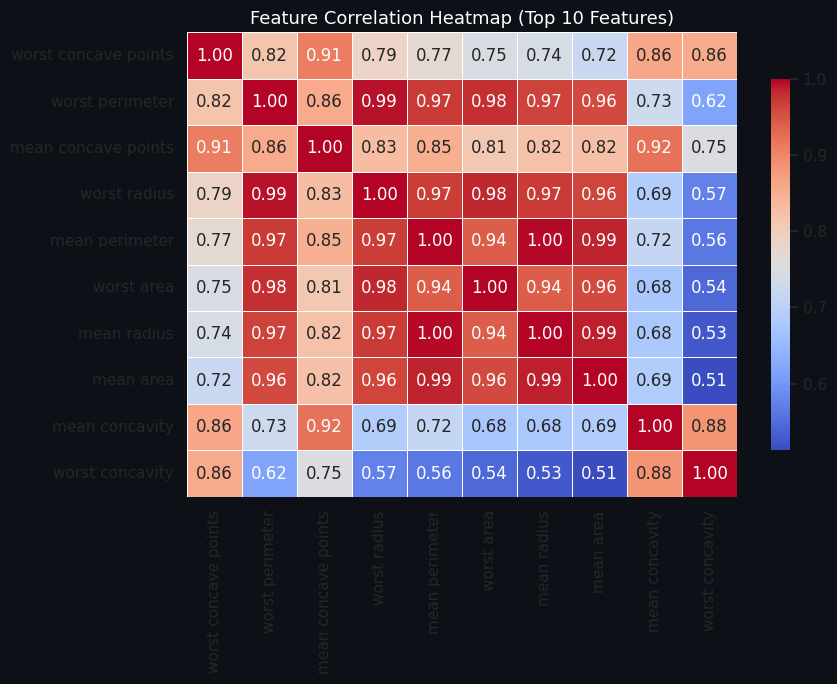

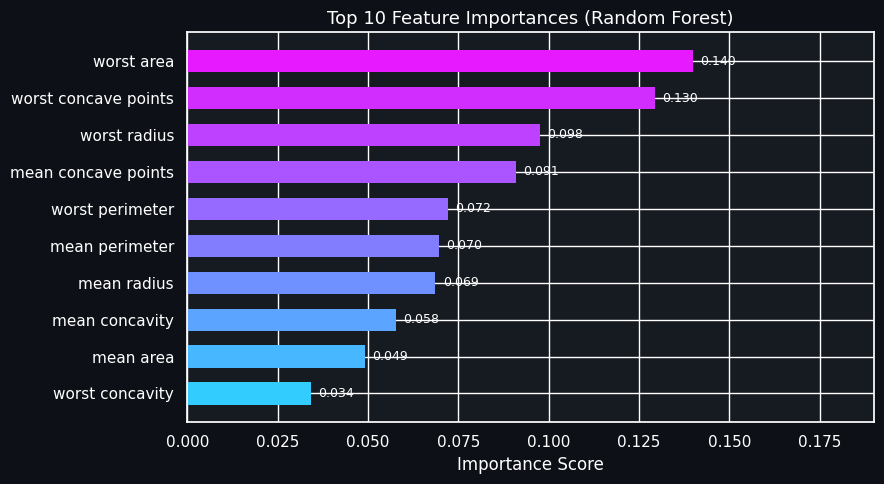


  KNN Classifier  (K = 5)
  Test Accuracy : 95.61%

Classification Report:

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



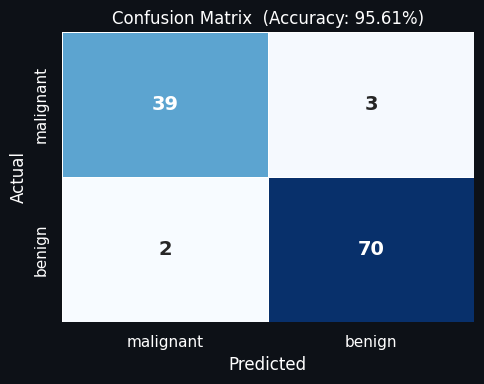

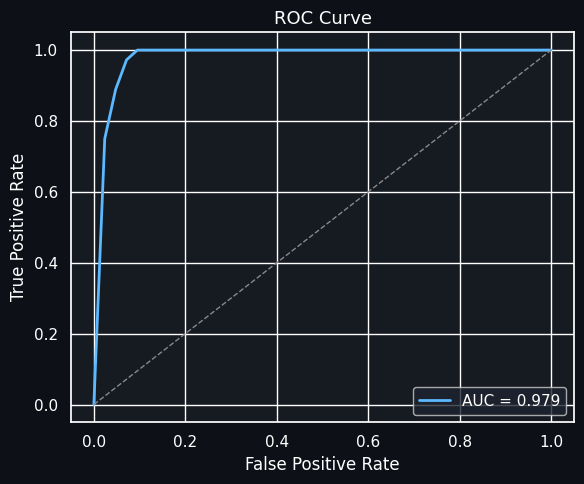


  ROC-AUC Score : 0.9788


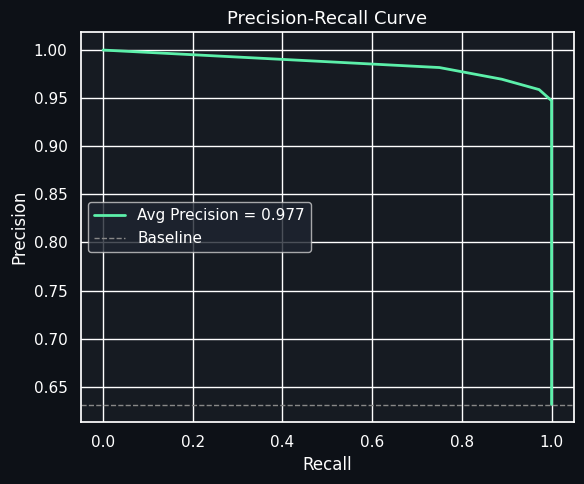

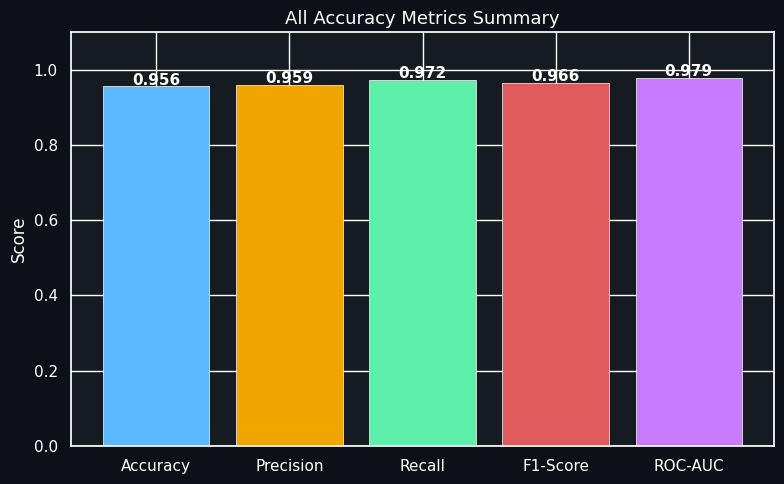


  Avg Precision (PR) : 0.9773
  Precision          : 0.9589
  Recall             : 0.9722
  F1-Score           : 0.9655
All plots saved as PNG files.


In [3]:
# ============================================================
#  K-Nearest Neighbours on the Breast Cancer Dataset
#  Covers: Preprocessing · Visualisations · Accuracy Metrics
# ============================================================

# ── 1. Imports ───────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score
)

# ── 2. Load Dataset ──────────────────────────────────────────
data   = load_breast_cancer()
X      = pd.DataFrame(data.data,   columns=data.feature_names)
y      = pd.Series(data.target,    name="target")
labels = data.target_names          # ['malignant', 'benign']

print("Dataset shape :", X.shape)
print("Classes       :", labels)
print("Class counts  :\n", y.value_counts().rename({0:"malignant", 1:"benign"}))
print("\nFirst 5 rows:\n", X.head())
print("\nBasic statistics:\n", X.describe().T[["mean","std","min","max"]].round(2))

# ── 3. Preprocessing ─────────────────────────────────────────
# 3a. Check for missing values
print("\nMissing values:", X.isnull().sum().sum())

# 3b. Train / test split (80 / 20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3c. Feature scaling  (KNN is distance-based → mandatory!)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\nTrain size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

# ── 4. Visualisations ────────────────────────────────────────
fig_style = dict(facecolor="#0d1117")
sns.set_theme(style="darkgrid", palette="muted")

# ─── 4a. Class Distribution ──────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4), **fig_style)
ax.set_facecolor("#161b22")
counts = y.value_counts().rename({0:"Malignant", 1:"Benign"})
bars   = ax.bar(counts.index, counts.values,
                color=["#e05c5c","#5cb8ff"], edgecolor="white", linewidth=0.6)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 3,
            str(val), ha="center", color="white", fontsize=12, fontweight="bold")
ax.set_title("Class Distribution", color="white", fontsize=14, pad=10)
ax.set_ylabel("Count", color="white");  ax.tick_params(colors="white")
plt.tight_layout(); plt.savefig("01_class_distribution.png", dpi=150); plt.show()

# ─── 4b. Feature Correlation Heatmap (top 10 features) ───────
top_feats = X.corrwith(y).abs().nlargest(10).index
fig, ax   = plt.subplots(figsize=(9, 7), **fig_style)
ax.set_facecolor("#161b22")
sns.heatmap(X[top_feats].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.4, ax=ax, cbar_kws={"shrink":0.8})
ax.set_title("Feature Correlation Heatmap (Top 10 Features)", color="white", fontsize=13)
plt.tight_layout(); plt.savefig("02_correlation_heatmap.png", dpi=150); plt.show()

best_k = 5  # default K

# ─── 4c. Feature Importance Bar Chart (via Random Forest) ────
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=data.feature_names).nlargest(10)

fig, ax = plt.subplots(figsize=(9, 5), **fig_style)
ax.set_facecolor("#161b22")
colors = plt.cm.cool(np.linspace(0.2, 0.9, len(importances)))
bars = ax.barh(importances.index[::-1], importances.values[::-1],
               color=colors, edgecolor="none", height=0.6)
for bar, val in zip(bars, importances.values[::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", color="white", fontsize=9)
ax.set_title("Top 10 Feature Importances (Random Forest)", color="white", fontsize=13)
ax.set_xlabel("Importance Score", color="white")
ax.tick_params(colors="white"); ax.set_xlim(0, importances.max() + 0.05)
plt.tight_layout(); plt.savefig("03_feature_importance.png", dpi=150); plt.show()

# ── 5. Train Final KNN Model ─────────────────────────────────
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred      = knn.predict(X_test)
y_pred_prob = knn.predict_proba(X_test)[:, 1]

# ── 6. Accuracy Metrics ──────────────────────────────────────
acc = accuracy_score(y_test, y_pred)
print(f"\n{'='*45}")
print(f"  KNN Classifier  (K = {best_k})")
print(f"{'='*45}")
print(f"  Test Accuracy : {acc*100:.2f}%")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=labels))

# ─── 6a. Confusion Matrix ─────────────────────────────────────
cm  = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4), **fig_style)
ax.set_facecolor("#161b22")
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=ax, cbar=False,
            annot_kws={"size":14, "weight":"bold"})
ax.set_title(f"Confusion Matrix  (Accuracy: {acc*100:.2f}%)", color="white", fontsize=12)
ax.set_xlabel("Predicted", color="white"); ax.set_ylabel("Actual", color="white")
ax.tick_params(colors="white")
plt.tight_layout(); plt.savefig("06_confusion_matrix.png", dpi=150); plt.show()

# ─── 6b. ROC Curve ───────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc     = auc(fpr, tpr)
fig, ax     = plt.subplots(figsize=(6, 5), **fig_style)
ax.set_facecolor("#161b22")
ax.plot(fpr, tpr, color="#5cb8ff", lw=2, label=f"AUC = {roc_auc:.3f}")
ax.plot([0,1],[0,1], color="#888", linestyle="--", lw=1)
ax.set_title("ROC Curve", color="white", fontsize=13)
ax.set_xlabel("False Positive Rate", color="white")
ax.set_ylabel("True Positive Rate",  color="white")
ax.tick_params(colors="white"); ax.legend(facecolor="#1e2430", labelcolor="white")
plt.tight_layout(); plt.savefig("07_roc_curve.png", dpi=150); plt.show()

print(f"\n  ROC-AUC Score : {roc_auc:.4f}")

# ─── 6c. Precision-Recall Curve ───────────────────────────────
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)
avg_precision = average_precision_score(y_test, y_pred_prob)
fig, ax = plt.subplots(figsize=(6, 5), **fig_style)
ax.set_facecolor("#161b22")
ax.plot(recall_vals, precision_vals, color="#5cf0aa", lw=2,
        label=f"Avg Precision = {avg_precision:.3f}")
ax.axhline(y=y_test.mean(), color="#888", linestyle="--", lw=1, label="Baseline")
ax.set_title("Precision-Recall Curve", color="white", fontsize=13)
ax.set_xlabel("Recall",    color="white")
ax.set_ylabel("Precision", color="white")
ax.tick_params(colors="white"); ax.legend(facecolor="#1e2430", labelcolor="white")
plt.tight_layout(); plt.savefig("08_precision_recall_curve.png", dpi=150); plt.show()

# ─── 6d. Metrics Summary Bar Chart ────────────────────────────
metric_names  = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
metric_values = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred),
    roc_auc
]
colours = ["#5cb8ff", "#f0a500", "#5cf0aa", "#e05c5c", "#c97bff"]
fig, ax = plt.subplots(figsize=(8, 5), **fig_style)
ax.set_facecolor("#161b22")
bars = ax.bar(metric_names, metric_values, color=colours, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f"{val:.3f}", ha="center", color="white", fontsize=11, fontweight="bold")
ax.set_ylim(0, 1.10)
ax.set_title("All Accuracy Metrics Summary", color="white", fontsize=13)
ax.set_ylabel("Score", color="white")
ax.tick_params(colors="white")
plt.tight_layout(); plt.savefig("09_metrics_summary.png", dpi=150); plt.show()

print(f"\n  Avg Precision (PR) : {avg_precision:.4f}")
print(f"  Precision          : {metric_values[1]:.4f}")
print(f"  Recall             : {metric_values[2]:.4f}")
print(f"  F1-Score           : {metric_values[3]:.4f}")
print(f"{'='*45}")
print("All plots saved as PNG files.")
